# Räumliche Vorhersage von Wartezeiten in der Notaufnahme über ein Versorgungsgebiet mit PROC KRIGE2D


## Kurzfassung

Ein Netzwerk-Betriebsteam eines Gesundheitssystems misst die durchschnittliche Wartezeit in der Notaufnahme (ED, in Minuten) an jeder besetzten Einrichtung in einem großstädtischen Versorgungsgebiet und möchte eine kontinuierliche Wartezeit-Oberfläche, um unterversorgte Lücken für einen neuen Notfallversorgungsstandort zu erkennen. Dieses Notebook erzeugt einen synthetischen Datensatz von **90 geokodierten Einrichtungen**, passt ein **gewöhnliches Kriging**-Modell (Ordinary Kriging) mit einem Nugget-Effekt an und interpoliert die ED-Wartezeiten über ein regelmäßiges Gitter, das das 50 km x 50 km große Versorgungsgebiet abdeckt, wodurch Punktvorhersagen und Kriging-Standardfehler an jedem Gitterknoten sowie an drei vorgeschlagenen Notfallversorgungsstandorten entstehen.

Über die 90 Einrichtungen hinweg beträgt die beobachtete Wartezeit im Durchschnitt **35,5 Minuten** (Spanne 7,5 bis 58,7). Die gekrigte Oberfläche reproduziert dieses Zentrum nahezu exakt (Mittelwert an den Gitterknoten **35,55 Minuten**) und reicht von **16,1** im ruhigen Südosten bis **56,4** im überlasteten Nordwesten, wo sich die Knoten mit vorhergesagten Spitzenwartezeiten rund um den innerstädtischen Andrang häufen. Von drei Kandidatenstandorten für die Notfallversorgung sagt der dem Stadtzentrum am nächsten gelegene die höchste Wartezeit voraus (**52,2 +/- 7,3 Minuten**), was ihn zum stärksten evidenzbasierten Standortargument macht.

## Datenquellen

Alle Daten sind synthetisch und werden inline im ersten DATA-Schritt erzeugt (`call streaminit(20260531)`). Es werden keine externen Dateien oder Netzwerkdateien verwendet.

| Datensatz | Zeilen | Variable | Typ | Beschreibung |
|-----------|--------|----------|-----|---------------|
| `ed_sites` | 90 | `east` | Num | Rechtswert (Ost-Koordinate) der Einrichtung in km (0-50) im Raster des Versorgungsgebiets |
| `ed_sites` | 90 | `north` | Num | Hochwert (Nord-Koordinate) der Einrichtung in km (0-50) im Raster des Versorgungsgebiets |
| `ed_sites` | 90 | `site_id` | Char | Einrichtungskennung (z. B. `FAC037`) |
| `ed_sites` | 90 | `wait_min` | Num | Beobachtete mittlere Wartezeit in der Notaufnahme in Minuten; eine räumlich korrelierte Oberfläche, die einen NW-SO-Überlastungsgradienten, einen innerstädtischen Andrang und lokales Rauschen kombiniert |

## Räumliche Vorhersage von ED-Wartezeiten mit PROC KRIGE2D

Ein regionales Gesundheitssystem betreibt **Notaufnahmen und Notfallversorgungskliniken**, die über ein 50 km x 50 km großes großstädtisches Versorgungsgebiet verteilt sind. Jede Einrichtung meldet ihre **durchschnittliche ED-Wartezeit** (Minuten). Die Wartezeiten sind räumlich korreliert: Der überlastete nordwestliche Stadtkern weist hohe Werte auf, während periphere südöstliche Einrichtungen niedrigere Werte aufweisen. Die Netzwerkplanung möchte eine *kontinuierliche* Wartezeit-Oberfläche mit Unsicherheitsangabe, um Lücken zu identifizieren, in denen ein neuer Notfallversorgungsstandort den größten Druck entlasten würde.

**PROC KRIGE2D** führt zweidimensionales gewöhnliches Kriging durch: Es nutzt ein Semivariogramm-Modell, um die gemessenen Wartezeiten auf ein Gitter von Standorten zu interpolieren, und liefert an jedem Knoten sowohl eine Vorhersage als auch einen Kriging-Standardfehler. Wir werden:

1. Einen realistischen synthetischen Einrichtungsdatensatz erzeugen.
2. Die beobachtete Wartezeitverteilung profilieren.
3. Mit einem sphärischen Modell plus Nugget-Effekt kriging und die Oberfläche untersuchen.
4. Direkt an drei Kandidatenstandorten für die Notfallversorgung vorhersagen.

## Schritt 1 - Synthetische Einrichtungsdaten erzeugen

Wir verteilen 90 Einrichtungen gleichmäßig über das Versorgungsgebiet. Die zugrunde liegende "wahre" Wartezeit-Oberfläche kombiniert einen glatten großräumigen Trend (einen NW-nach-SO-Überlastungsgradienten plus eine zentrale innerstädtische Erhebung nahe (15, 38)) mit einem glatten regionalen Wirbel, sodass das Feld tatsächlich räumlich autokorreliert ist und nicht reines Rauschen darstellt. Wir fügen ein kleines Mess-Nugget hinzu, um die tägliche Schwankung bei der Meldung nachzubilden.

In [1]:
DATEN ed_sites;
   AUFRUFEN streaminit(20260531);
   LÄNGE site_id $6;
   AUSFÜHRUNG i = 1 BIS 90;
      east  = 50 * rand('uniform');
      north = 50 * rand('uniform');

      /* Large-scale congestion trend: high in the NW downtown core,
         tapering toward the SE suburban edge */
      trend = 18
            + 0.32 * (50 - east)
            + 0.28 * north;

      /* Central downtown surge centered near (15, 38) */
      dist2 = (east - 15)**2 + (north - 38)**2;
      surge = 22 * EXP(-dist2 / 160);

      /* Smooth regional eddy to create realistic autocorrelation */
      eddy  = 6 * sin(east/9) * cos(north/11);

      /* Local reporting noise (measurement nugget) */
      noise = 4 * rand('normal');

      wait_min = round(trend + surge + eddy + noise, 0.1);
      WENN wait_min < 3 DANN wait_min = 3;

      site_id = cats('FAC', PUT(i, z3.));
      AUSGABE;
   ENDE;
   BEHALTEN site_id east north wait_min;
AUSFÜHREN;

PROZEDUR DRUCKEN DATEN=ed_sites(obs=10) noobs;
   TITEL 'Erste 10 synthetische Notaufnahme-Einrichtungen (km-Koordinaten, Wartezeit in Minuten)';
   VAR site_id east north wait_min;
   BEZEICHNUNG site_id='Einrichtungs-ID' east='Ost (km)' north='Nord (km)' wait_min='Wartezeit (Min.)';
AUSFÜHREN;

                 Erste 10 synthetische Notaufnahme-Einrichtungen (km-Koordinaten, Wartezeit in Minuten)                 

Einrichtungs-ID       Ost (km)      Nord (km)  Wartezeit (Min.)
FAC001           42.1064239035  44.8746335392              36.7
FAC002           10.6189061789  14.5101311244              36.2
FAC003           48.9064287162    18.61727984              17.7
FAC004            45.555283186   43.264675772              34.5
FAC005           32.9816533373  24.7120124541              32.5
FAC006           31.1796232687  19.1168441231              31.4
FAC007           34.6664652019  35.2149577448              39.2
FAC008           40.5104234712   2.9588781811              17.1
FAC009            9.9213354522  40.5368804705              54.3
FAC010           24.5041747799  22.5897811072              35.9

... 80 more observations (showing 10 of 90)




NOTE: DATA ed_sites


NOTE: Wrote ed_sites (90 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC PRINT data=ed_sites

NOTE: PROC PRINT completed: 10 observations printed, 4 variables


## Schritt 2 - Die beobachteten Wartezeiten profilieren

Vor dem Kriging bestätigen wir, dass die Oberfläche sinnvoll verteilt ist. Eine kurze `PROC MEANS`-Zusammenfassung liefert uns die Spannweite und die zentrale Tendenz, die die gekrigte Oberfläche reproduzieren sollte. Die 90 Einrichtungen weisen im Durchschnitt **35,5 Minuten** bei einer Standardabweichung von **10,6** auf, mit einer Spanne von **7,5** an der ruhigsten Vorstadteinrichtung bis **58,7** an der am stärksten überlasteten innerstädtischen Einrichtung - eine breite, realistische Streuung für ein Interpolationsziel.

In [2]:
PROZEDUR MITTELWERTE DATEN=ed_sites n mean std MIN p25 MEDIAN p75 MAX maxdec=1;
   TITEL 'Beobachtete Verteilung der ED-Wartezeiten über die Einrichtungen';
   VAR wait_min;
   BEZEICHNUNG wait_min = 'Wartezeit (Min.)';
AUSFÜHREN;

                            Beobachtete Verteilung der ED-Wartezeiten über die Einrichtungen                            

                                                  The MEANS Procedure

 Variable  Label                   N        Mean     Std Dev     Minimum   Lower Quartile      Median   Upper Quartile     Maximum
 ---------------------------------------------------------------------------------------------------------------------------------
 wait_min  Wartezeit (Min.)       90        35.5        10.6         7.5             29.1        35.7             39.5        58.7
 ---------------------------------------------------------------------------------------------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Schritt 3 - Gewöhnliches Kriging mit einem sphärischen Modell

Die `COORDINATES`-Anweisung benennt die räumlichen Achsen, `PREDICT VAR=` benennt die Analysevariable und legt die Suchumgebung fest, und `MODEL` liefert das Semivariogramm. Wir verwenden eine **sphärische** Form (eine Standardwahl, wenn die Korrelation bei endlicher Reichweite auf null abklingt), mit:

- `SCALE=120` - der partielle Schwellenwert (Sill; die durch räumliche Struktur erklärte Varianz),
- `RANGE=18` - die Korrelation erreicht bei etwa 18 km das Hintergrundniveau,
- `NUGGET=14` - die Mess-/Melde-Diskontinuität bei Distanz null.

Wir interpolieren auf ein regelmäßiges **9 x 9 = 81-Knoten**-Gitter, das das gesamte Versorgungsgebiet abdeckt (`GRID X=0 TO 50 BY 6 Y=0 TO 50 BY 6`) - grob genug, um jeden Knoten direkt zusammenzufassen und zu ranken, fein genug, um die Struktur abzubilden. `OUTEST=` erfasst die gitterbasierten Vorhersagen und Standardfehler; `OUTNBHD=` verzeichnet, wie viele Einrichtungen in jede lokale Lösung eingegangen sind. `PLOTS=` fordert die Karte der beobachteten Daten und die Vorhersage-Konturkarte an, gefüllt nach Standardfehler.

                            Beobachtete Verteilung der ED-Wartezeiten über die Einrichtungen                            

   The KRIGE2D Procedure    
     Model Information      

Item                   Value
-----------------  ---------
Variogram Model    SPHERICAL
Kriging Method      ORDINARY
Observations Used         90
Prediction Points         81




NOTE: PROC KRIGE2D: Two-Dimensional Kriging
NOTE: Using Python scipy version 1.16.3
NOTE: PROC KRIGE2D results written to: ./ods_output/krige2d_results.json
NOTE: Wrote krige_sph (81 rows, 4 columns).


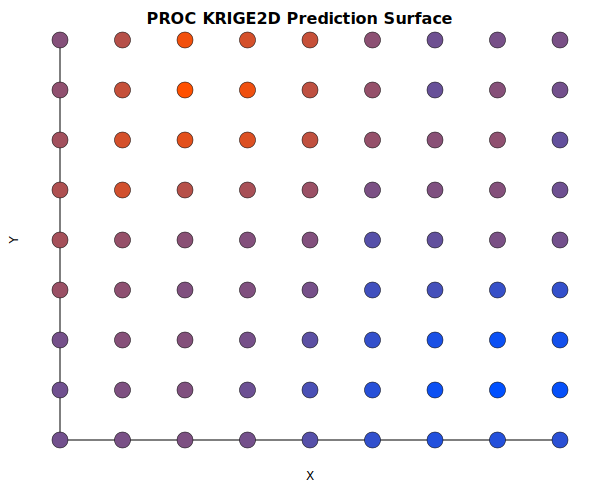

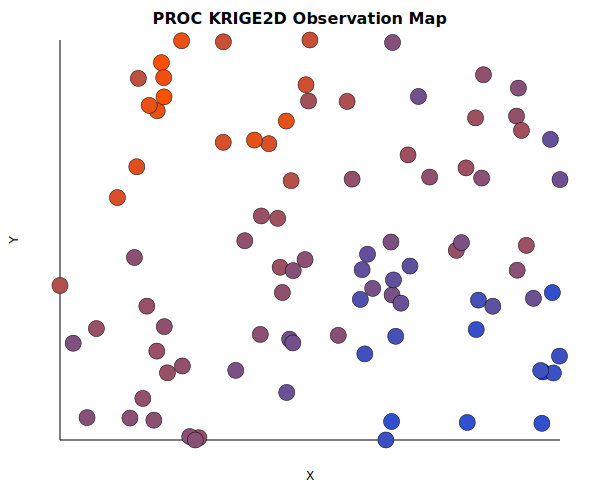

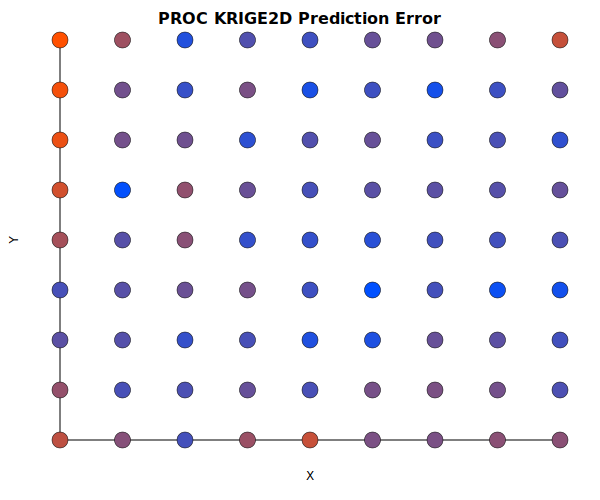

In [3]:
PROZEDUR krige2d DATEN=ed_sites outest=krige_sph outnbhd=nbhd_sph
      PLOTS(only)=(observations prediction(fill=pred line=se));
   TITEL 'Gewöhnliches Kriging der ED-Wartezeiten - Sphärisches Modell';
   COORDINATES XC=east YC=north;
   predict VAR=wait_min radius=20 minpoints=10 maxpoints=40;
   MODELL FORM=spherical SCALE=120 range=18 NUGGET=14;
   grid x=0 BIS 50 NACH 6 y=0 BIS 50 NACH 6;
AUSFÜHREN;

## Schritt 4 - Die gekrigte Oberfläche untersuchen

Der `OUTEST=`-Datensatz enthält eine Zeile je Gitterknoten mit der vorhergesagten Wartezeit (`estimate`) und ihrem Kriging-Standardfehler (`stderr`). Wir fassen die Oberfläche zusammen und markieren die heißesten vorhergesagten Knoten - Kandidatenzonen, in denen ein neuer Notfallversorgungsstandort den größten Druck entlasten würde.

Der Mittelwert der gekrigten Oberfläche (**35,55 Minuten**) folgt dem beobachteten Einrichtungsdurchschnitt (35,5) nahezu exakt - ein Plausibilitätscheck, dass das gewöhnliche Kriging erwartungstreu ist. Die Vorhersagen reichen von **16,1** im dünn besiedelten Südosten bis **56,4** im überlasteten Nordwesten; die Standardfehler reichen von **5,1**, wo Einrichtungen dicht liegen, bis **11,2** in dünn besetzten Ecken. Die sechs heißesten Knoten liegen alle im NW-Quadranten um (12-18, 36-48), genau auf dem innerstädtischen Andrang, der in die synthetischen Daten eingebaut wurde.

In [4]:
PROZEDUR MITTELWERTE DATEN=krige_sph n mean MIN MAX maxdec=2;
   TITEL 'Zusammenfassung der gekrigten Oberfläche (vorhergesagte Wartezeit in Minuten und Standardfehler)';
   VAR SCHÄTZUNG stderr;
   BEZEICHNUNG SCHÄTZUNG='Vorhersage (Min.)' stderr='Standardfehler (Min.)';
AUSFÜHREN;

PROZEDUR SORTIEREN DATEN=krige_sph out=hot_nodes;
   NACH ABSTEIGEND SCHÄTZUNG;
AUSFÜHREN;

PROZEDUR DRUCKEN DATEN=hot_nodes(obs=6) noobs;
   TITEL 'Sechs Gitterknoten mit den höchsten vorhergesagten ED-Wartezeiten';
   VAR x y SCHÄTZUNG stderr;
   BEZEICHNUNG x='Ost (km)' y='Nord (km)' SCHÄTZUNG='Vorhersage (Min.)' stderr='Standardfehler (Min.)';
AUSFÜHREN;

            Zusammenfassung der gekrigten Oberfläche (vorhergesagte Wartezeit in Minuten und Standardfehler)            

                                                  The MEANS Procedure

 Variable  Label                        N        Mean     Minimum     Maximum
 ----------------------------------------------------------------------------
 ESTIMATE  Vorhersage (Min.)           81       35.55       16.07       56.38
 STDERR    Standardfehler (Min.)       81        7.38        5.06       11.20
 ----------------------------------------------------------------------------

                           Sechs Gitterknoten mit den höchsten vorhergesagten ED-Wartezeiten                            

Ost (km)  Nord (km)  Vorhersage (Min.)  Standardfehler (Min.)
      12         42      56.3838526129           6.3860887297
      12         48       54.379464215            5.876759721
      18         42        53.81777091           8.0028060667
      12         36      51.9499223116        


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC SORT data=krige_sph

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 81 rows from krige_sph.
NOTE: Wrote hot_nodes (81 rows, 4 columns).
NOTE: PROC SORT statement used.
NOTE: PROC PRINT data=hot_nodes

NOTE: PROC PRINT completed: 6 observations printed, 4 variables


## Schritt 5 - Vorhersage an bestimmten Kandidatenstandorten

Die Netzwerkplanung hat drei vorgeschlagene Standorte für die Notfallversorgung. Wir krigen direkt an jedem Punkt, indem wir ihn als Ein-Knoten-Gitter angeben (`GRID X=cx TO cx BY 1 Y=cy TO cy BY 1`), was den Planern die vorhergesagte Wartezeit und ihren Kriging-Standardfehler an der exakten Koordinate liefert.

Der Kandidat nahe dem Stadtzentrum, **(14, 37)**, liefert die höchste vorhergesagte Wartezeit - **52,2 +/- 7,3 Minuten** - und bestätigt, dass er Nachfrage von den am stärksten frequentierten Notaufnahmen aufnehmen würde. Der südöstliche Kandidat **(32, 12)** sitzt in der ruhigen Vorstadtecke bei **22,0 +/- 6,2**, und der nordöstliche Kandidat **(42, 44)** liegt im mittleren Bereich bei **36,4 +/- 5,9**. Allein anhand der vorhergesagten Wartezeit ist der innerstädtische Kandidat das stärkste evidenzbasierte Standortargument.

In [5]:
PROZEDUR krige2d DATEN=ed_sites outest=cand_dt PLOTS=none;
   TITEL 'Kandidat A - Innenstadtkern (14, 37)';
   COORDINATES XC=east YC=north;
   predict VAR=wait_min radius=20 minpoints=8 maxpoints=40;
   MODELL FORM=spherical SCALE=120 range=18 NUGGET=14;
   grid x=14 BIS 14 NACH 1 y=37 BIS 37 NACH 1;
AUSFÜHREN;

PROZEDUR krige2d DATEN=ed_sites outest=cand_se PLOTS=none;
   TITEL 'Kandidat B - Vorstadt Südosten (32, 12)';
   COORDINATES XC=east YC=north;
   predict VAR=wait_min radius=20 minpoints=8 maxpoints=40;
   MODELL FORM=spherical SCALE=120 range=18 NUGGET=14;
   grid x=32 BIS 32 NACH 1 y=12 BIS 12 NACH 1;
AUSFÜHREN;

PROZEDUR krige2d DATEN=ed_sites outest=cand_ne PLOTS=none;
   TITEL 'Kandidat C - Nordost-Rand (42, 44)';
   COORDINATES XC=east YC=north;
   predict VAR=wait_min radius=20 minpoints=8 maxpoints=40;
   MODELL FORM=spherical SCALE=120 range=18 NUGGET=14;
   grid x=42 BIS 42 NACH 1 y=44 BIS 44 NACH 1;
AUSFÜHREN;

DATEN candidates;
   FESTLEGEN cand_dt cand_se cand_ne;
AUSFÜHREN;

PROZEDUR DRUCKEN DATEN=candidates noobs;
   TITEL 'Vorhergesagte ED-Wartezeiten an drei Kandidatenstandorten für die Notfallversorgung';
   VAR x y SCHÄTZUNG stderr;
   BEZEICHNUNG x='Ost (km)' y='Nord (km)' SCHÄTZUNG='Vorhersage (Min.)' stderr='Standardfehler (Min.)';
AUSFÜHREN;

                           Sechs Gitterknoten mit den höchsten vorhergesagten ED-Wartezeiten                            

   The KRIGE2D Procedure    
     Model Information      

Item                   Value
-----------------  ---------
Variogram Model    SPHERICAL
Kriging Method      ORDINARY
Observations Used         90
Prediction Points          1

          Kriging Predictions          

       X         Y  Estimate  Std Error
--------  --------  --------  ---------
   14.00     37.00   52.1916     7.2579

                           Sechs Gitterknoten mit den höchsten vorhergesagten ED-Wartezeiten                            

   The KRIGE2D Procedure    
     Model Information      

Item                   Value
-----------------  ---------
Variogram Model    SPHERICAL
Kriging Method      ORDINARY
Observations Used         90
Prediction Points          1

          Kriging Predictions          

       X         Y  Estimate  Std Error
--------  --------  --------  ---------
   32


NOTE: PROC KRIGE2D: Two-Dimensional Kriging
NOTE: Using Python scipy version 1.16.3
NOTE: PROC KRIGE2D results written to: ./ods_output/krige2d_results.json
NOTE: Wrote cand_dt (1 rows, 4 columns).
NOTE: PROC KRIGE2D: Two-Dimensional Kriging
NOTE: Using Python scipy version 1.16.3
NOTE: PROC KRIGE2D results written to: ./ods_output/krige2d_results.json
NOTE: Wrote cand_se (1 rows, 4 columns).
NOTE: PROC KRIGE2D: Two-Dimensional Kriging
NOTE: Using Python scipy version 1.16.3
NOTE: PROC KRIGE2D results written to: ./ods_output/krige2d_results.json
NOTE: Wrote cand_ne (1 rows, 4 columns).
NOTE: DATA candidates


NOTE: Read 1 rows from cand_dt.
NOTE: Read 2 rows from cand_se.
NOTE: Read 3 rows from cand_ne.
NOTE: Wrote candidates (3 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=candidates

NOTE: PROC PRINT completed: 3 observations printed, 4 variables


## Die Ergebnisse interpretieren

- **Die gekrigte Oberfläche bildet die Überlastungsstruktur des Versorgungsgebiets ab.** Das sphärische Ordinary-Kriging-Modell interpoliert ein glattes Wartezeitfeld, dessen Mittelwert an den Gitterknoten (35,55 Min.) dem beobachteten Einrichtungsdurchschnitt (35,5 Min.) entspricht, mit den höchsten vorhergesagten Wartezeiten - bis zu 56,4 Minuten - konzentriert im NW-Quadranten rund um den innerstädtischen Andrang nahe (15, 38), den wir in die synthetischen Daten eingebaut haben. Diese Übereinstimmung ist ein Plausibilitätscheck, dass sich das Modell korrekt verhält.
- **Standardfehler lokalisieren die Konfidenz.** Der Kriging-Standardfehler reicht von 5,1 Minuten, wo Einrichtungen dicht liegen, bis 11,2 in den dünn besetzten Ecken des Versorgungsgebiets. Planer sollten Vorhersagen in Zonen mit hohem `stderr` mit Vorsicht behandeln; das sind auch die Bereiche, in denen eine zusätzliche Einrichtung sowohl die künftige Abdeckung als auch die künftige Messung am stärksten verbessern würde.
- **Punktvorhersagen unterstützen Standortentscheidungen.** Das direkte Kriging der drei Kandidatenstandorte macht aus der Oberfläche eine handlungsfähige Tabelle. Der innerstädtische Kandidat (14, 37) zeigt die höchste vorhergesagte Wartezeit (52,2 Min.) mit einem moderaten Standardfehler (7,3), was ihn zum stärksten evidenzbasierten Fall für einen neuen Notfallversorgungsstandort macht, um die am stärksten frequentierte Notaufnahme zu entlasten; der Kandidat im Vorstadt-Südosten (32, 12) sitzt in einer Ecke mit geringer Nachfrage (22,0 Min.), und der Kandidat am Nordost-Rand (42, 44) liegt im mittleren Bereich (36,4 Min.).

In der Praxis würden die Semivariogramm-Parameter (`SCALE`, `RANGE`, `NUGGET`) empirisch mit PROC VARIOGRAM geschätzt und dann an KRIGE2D übergeben - entweder als explizite Werte wie hier gezeigt, oder automatisch über `RESTORE` aus einem VARIOGRAM-Item-Store.